# Credit Card Fraud Detection — Modeling & Imbalanced Learning

Benchmark Logistic Regression, LightGBM, and XGBoost with class weighting, SMOTE, and random undersampling.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from src.features import add_time_features, add_training_volume_feature
from src.preprocessing import make_preprocessor

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
SMOTE_SAMPLING_STRATEGY = 0.10
UNDERSAMPLING_STRATEGY = 0.10

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:.5f}")
sns.set_theme(style="whitegrid")


## 2. Load the Dataset

The notebook starts from the raw dataset so each cross-validation pipeline can fit preprocessing within its training folds.

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")


Dataset shape: (284807, 31)


## 3. Recreate the Stratified Train/Test Split

The test set is reserved for the final holdout evaluation. Model selection uses the training set only.

In [3]:
from sklearn.model_selection import train_test_split

TARGET = "Class"

X = df.drop(columns=TARGET).copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")
print(f"Training fraud rate: {y_train.mean():.4%}")
print(f"Testing fraud rate:  {y_test.mean():.4%}")


Training rows: 227,845
Testing rows:  56,962
Training fraud rate: 0.1729%
Testing fraud rate:  0.1720%


## 4. Feature Engineering

Use the reusable feature-engineering functions from `src.features`. The transaction-volume mapping is learned from the training split before cross-validation; it is target-independent but not yet fold-specific.

In [4]:
X_train_fe = add_time_features(X_train)
X_test_fe = add_time_features(X_test)

X_train_fe, X_test_fe, hourly_counts = add_training_volume_feature(
    X_train_fe,
    X_test_fe,
)

print(f"Training features: {X_train_fe.shape}")
print(f"Testing features:  {X_test_fe.shape}")
print(f"Hourly buckets learned: {len(hourly_counts)}")


Training features: (227845, 35)
Testing features:  (56962, 35)
Hourly buckets learned: 48


In [6]:
X_train_fe = add_time_features(X_train)
X_test_fe = add_time_features(X_test)

X_train_fe, X_test_fe,_ = add_training_volume_feature(
    X_train_fe,
    X_test_fe,
)

print(f"Training features: {X_train_fe.shape}")
print(f"Testing features:  {X_test_fe.shape}")


Training features: (227845, 35)
Testing features:  (56962, 35)


## 5. Define Preprocessing

`make_preprocessor()` returns the same preprocessing used in Stage 2. It is placed inside each modeling pipeline so scaler statistics are fitted separately within each CV fold.

In [7]:
preprocessor = make_preprocessor()

## 6. Establish Class Weight

`scale_pos_weight` is computed from the training class counts and used by the weighted LightGBM and XGBoost experiments.

In [8]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

print(f"Negative training cases: {negative_count:,}")
print(f"Positive training cases: {positive_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


Negative training cases: 227,451
Positive training cases: 394
scale_pos_weight: 577.29


## 7. Define Candidate Models

The initial benchmark uses fixed, reasonable configurations rather than a large hyperparameter search. The purpose is to compare model families and imbalance strategies.

In [9]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

model_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

models = {
    "Logistic Regression — balanced": LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "LightGBM — weighted": LGBMClassifier(
        **model_params,
        num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        verbosity=-1,
    ),
    "LightGBM — unweighted": LGBMClassifier(
        **model_params,
        num_leaves=31,
        verbosity=-1,
    ),
    "XGBoost — weighted": XGBClassifier(
        **model_params,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
    ),
    "XGBoost — unweighted": XGBClassifier(
        **model_params,
        max_depth=6,
        eval_metric="aucpr",
    ),
}

print(f"Training class ratio: {scale_pos_weight:.2f}:1")

Training class ratio: 577.29:1


## 8. Define Resampling Experiments

SMOTE and random undersampling are applied inside the imbalanced-learn pipelines, so resampling occurs separately within each training fold.

In [10]:
def build_pipeline(model, sampling=None):
    steps = [("preprocessor", clone(preprocessor))]

    if sampling == "smote":
        steps.append((
            "sampler",
            SMOTE(
                sampling_strategy=SMOTE_SAMPLING_STRATEGY,
                random_state=RANDOM_STATE,
            ),
        ))
    elif sampling == "undersampling":
        steps.append((
            "sampler",
            RandomUnderSampler(
                sampling_strategy=UNDERSAMPLING_STRATEGY,
                random_state=RANDOM_STATE,
            ),
        ))

    steps.append(("model", model))
    return ImbPipeline(steps=steps)


## 9. Build the Experiment Matrix

The benchmark covers:

- Logistic Regression with class weighting
- LightGBM with class weighting, SMOTE, and undersampling
- XGBoost with class weighting, SMOTE, and undersampling

In [11]:
experiments = {
    "Logistic Regression — balanced": build_pipeline(
        clone(models["Logistic Regression — balanced"])
    ),
    "LightGBM — weighted": build_pipeline(
        clone(models["LightGBM — weighted"])
    ),
    "LightGBM — SMOTE": build_pipeline(
        clone(models["LightGBM — unweighted"]),
        sampling="smote",
    ),
    "LightGBM — undersampling": build_pipeline(
        clone(models["LightGBM — unweighted"]),
        sampling="undersampling",
    ),
    "XGBoost — weighted": build_pipeline(
        clone(models["XGBoost — weighted"])
    ),
    "XGBoost — SMOTE": build_pipeline(
        clone(models["XGBoost — unweighted"]),
        sampling="smote",
    ),
    "XGBoost — undersampling": build_pipeline(
        clone(models["XGBoost — unweighted"]),
        sampling="undersampling",
    ),
}

for name in experiments:
    print("-", name)

- Logistic Regression — balanced
- LightGBM — weighted
- LightGBM — SMOTE
- LightGBM — undersampling
- XGBoost — weighted
- XGBoost — SMOTE
- XGBoost — undersampling


## 10. Stratified Cross-Validation

Five-fold stratified cross-validation preserves the rare fraud class in every fold. PR-AUC is the primary selection metric; ROC-AUC, precision, recall, and F1 are recorded for comparison.

In [12]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv_results = []

for name, pipeline in experiments.items():
    print(f"Running: {name}")

    scores = cross_validate(
        pipeline,
        X_train_fe,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    cv_results.append({
        "experiment": name,
        "pr_auc_mean": scores["test_pr_auc"].mean(),
        "pr_auc_std": scores["test_pr_auc"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": scores["test_f1"].mean(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("pr_auc_mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df)


Running: Logistic Regression — balanced
Running: LightGBM — weighted
Running: LightGBM — SMOTE
Running: LightGBM — undersampling
Running: XGBoost — weighted
Running: XGBoost — SMOTE
Running: XGBoost — undersampling


,experiment,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,recall_mean,f1_mean
0,LightGBM — SMOTE,0.85737,0.02366,0.98098,0.00915,0.88562,0.82243,0.85132
1,XGBoost — SMOTE,0.85527,0.02729,0.98168,0.01017,0.86511,0.82749,0.84400
2,XGBoost — weighted,0.84717,0.02379,0.98274,0.01081,0.88867,0.81983,0.85104
3,XGBoost — undersampling,0.77507,0.06364,0.98338,0.00991,0.48678,0.85534,0.61773
4,LightGBM — undersampling,0.77111,0.05777,0.98243,0.01028,0.51098,0.85028,0.63578
5,Logistic Regression — balanced,0.75590,0.05161,0.98371,0.01054,0.05906,0.92136,0.11097
6,LightGBM — weighted,0.61802,0.07545,0.92496,0.02394,0.04429,0.83752,0.08294


## 11. Compare PR-AUC Across Experiments

PR-AUC is emphasized because the fraud class is extremely rare.

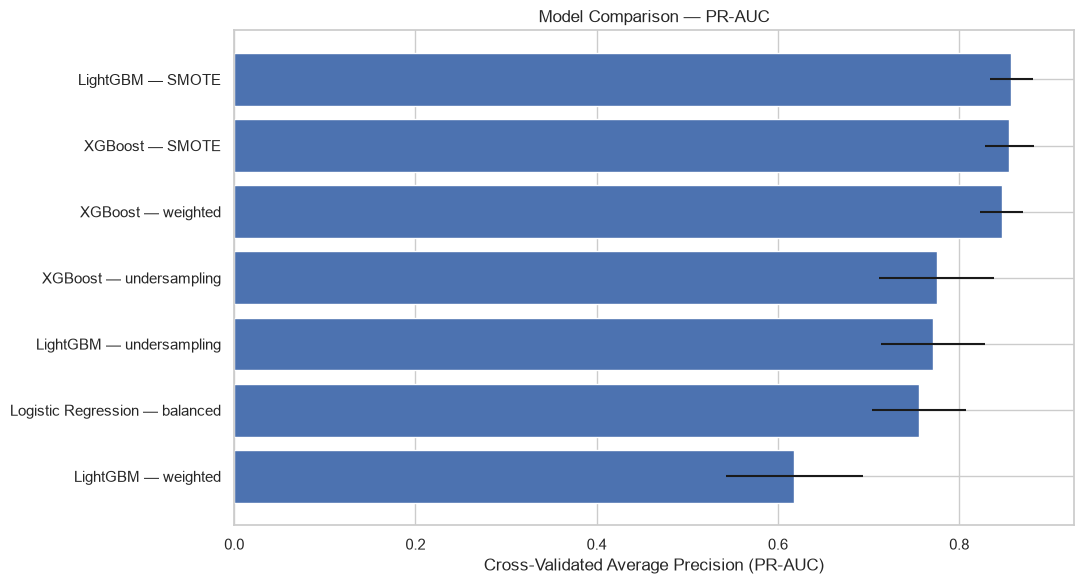

In [13]:
plt.figure(figsize=(11, 6))

plot_df = cv_results_df.sort_values("pr_auc_mean")

plt.barh(
    plot_df["experiment"],
    plot_df["pr_auc_mean"],
    xerr=plot_df["pr_auc_std"],
)

plt.xlabel("Cross-Validated Average Precision (PR-AUC)")
plt.ylabel("")
plt.title("Model Comparison — PR-AUC")
plt.tight_layout()
plt.show()


## 12. Compare ROC-AUC

ROC-AUC is reported as a secondary ranking metric.

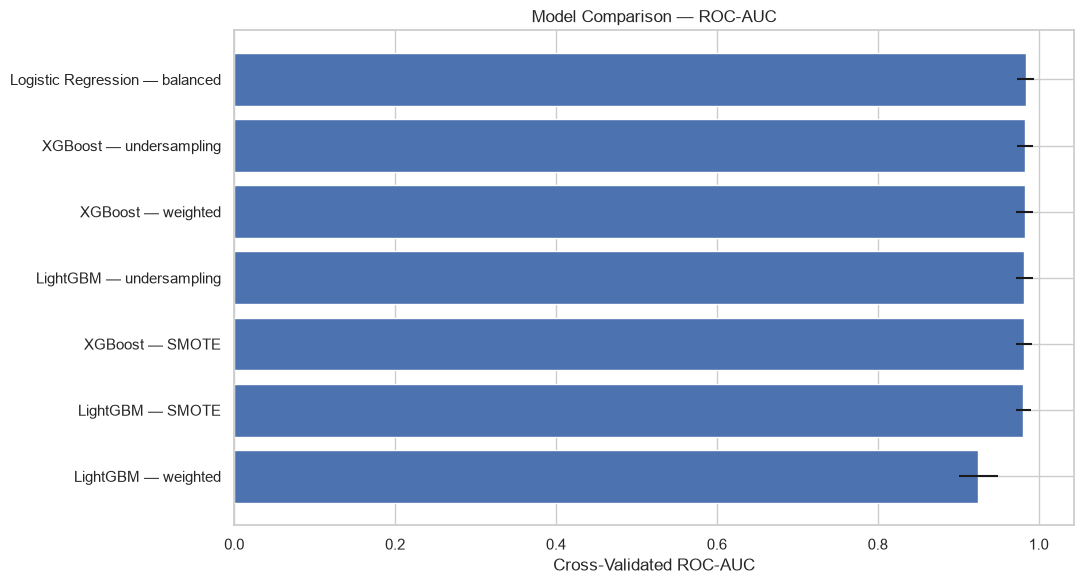

In [14]:
plt.figure(figsize=(11, 6))

plot_df = cv_results_df.sort_values("roc_auc_mean")

plt.barh(
    plot_df["experiment"],
    plot_df["roc_auc_mean"],
    xerr=plot_df["roc_auc_std"],
)

plt.xlabel("Cross-Validated ROC-AUC")
plt.ylabel("")
plt.title("Model Comparison — ROC-AUC")
plt.tight_layout()
plt.show()


## 13. Select the Leading Candidate

Select the experiment with the highest mean cross-validated PR-AUC. The test set remains untouched during this decision.

In [15]:
best_experiment_name = cv_results_df.iloc[0]["experiment"]
best_pipeline = experiments[best_experiment_name]

print(f"Leading candidate: {best_experiment_name}")
print(f"Mean CV PR-AUC: {cv_results_df.iloc[0]['pr_auc_mean']:.5f}")
print(f"Mean CV ROC-AUC: {cv_results_df.iloc[0]['roc_auc_mean']:.5f}")


Leading candidate: LightGBM — SMOTE
Mean CV PR-AUC: 0.85737
Mean CV ROC-AUC: 0.98098


## 14. Fit the Leading Candidate on the Full Training Set

Fit the selected pipeline on the complete training split and evaluate it on the held-out test set at the default `0.5` threshold. Threshold selection is handled in Stage 4.

In [16]:
best_pipeline.fit(X_train_fe, y_train)

test_probabilities = best_pipeline.predict_proba(X_test_fe)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

test_pr_auc = average_precision_score(y_test, test_probabilities)
test_roc_auc = roc_auc_score(y_test, test_probabilities)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0,
)

print(f"Final test PR-AUC:  {test_pr_auc:.5f}")
print(f"Final test ROC-AUC: {test_roc_auc:.5f}")
print(f"Test precision @ 0.5: {test_precision:.5f}")
print(f"Test recall @ 0.5:    {test_recall:.5f}")
print(f"Test F1 @ 0.5:        {test_f1:.5f}")


Final test PR-AUC:  0.87444
Final test ROC-AUC: 0.97930
Test precision @ 0.5: 0.82000
Test recall @ 0.5:    0.83673
Test F1 @ 0.5:        0.82828


## 15. Holdout Confusion Matrix

The `0.5` threshold is a diagnostic baseline only. The final operating threshold is selected from out-of-fold predictions in Stage 4.

In [17]:
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Fraud", "Actual Fraud"],
    columns=["Predicted Non-Fraud", "Predicted Fraud"],
)

display(cm_df)

print(classification_report(
    y_test,
    test_predictions,
    target_names=["Non-Fraud", "Fraud"],
    zero_division=0,
))


,Predicted Non-Fraud,Predicted Fraud
Actual Non-Fraud,56846,18
Actual Fraud,16,82


              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.82      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## 16. Stage 3 Conclusions

The completed benchmark provides the model/imbalance configuration used for Stage 4 threshold tuning and interpretability.